In [1]:
import os as os
import sys

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.ligoHistogram import ligoHistogram
from scripts.wosa import wosa
from scripts.psdAndPlot import plotLigoPsd
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeriesDict

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
bethLISA_directory = os.path.join(os.getcwd(), "..", "..", "bethLISA")
tdi_path = os.path.join(bethLISA_directory, 'lisa_glitch_simulation',
                        'tdi_outputs', 'vsmall_glitch_tdi.h5')
obs = TimeSeriesDict.read(tdi_path)
data = obs["X"].value
dt  = obs["X"].dt.value
t = obs["X"].times.value 

Number of segments: 16
Exiting custom wosa


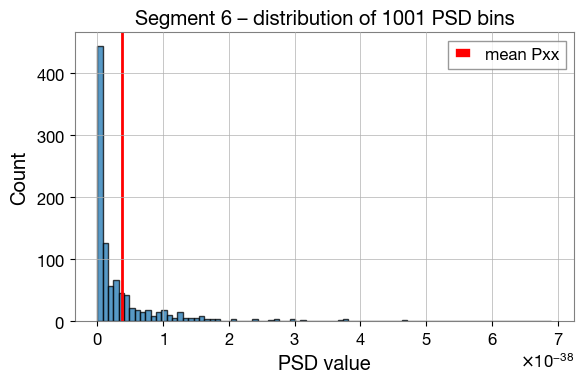

Number of segments: 16
Exiting custom wosa


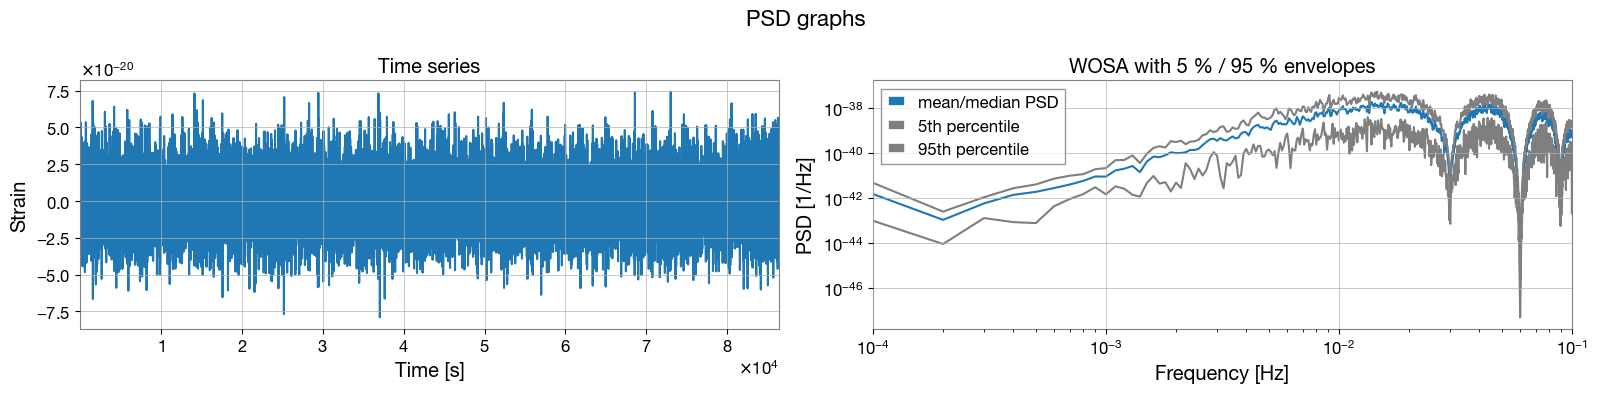

In [3]:
f, Pxx, P_stack = wosa(data,
    fs= 1.0 / dt,
    nperseg= 2000
)
ligoHistogram(P_stack, Pxx, seg_idx=5)

plotLigoPsd(data, t, dt, nper=2000, title='Strain')